# 4. Model Evaluation & Benchmarking
Renders the performance outputs, AUC charts, and confusion matrices utilizing the test-set cache generated by the baseline modeling stage.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, precision_recall_curve, auc
import time
%matplotlib inline

# Load serialized models and matrices
trained_models = joblib.load('../../models/all_trained_models.pkl')
X_train, X_test, y_train_churn, y_test_churn, X_train_scaled, X_test_scaled = joblib.load('../../models/train_test_data.pkl')

print('Test Set loaded successfully: ', X_test.shape)


Test Set loaded successfully:  (15665, 120)


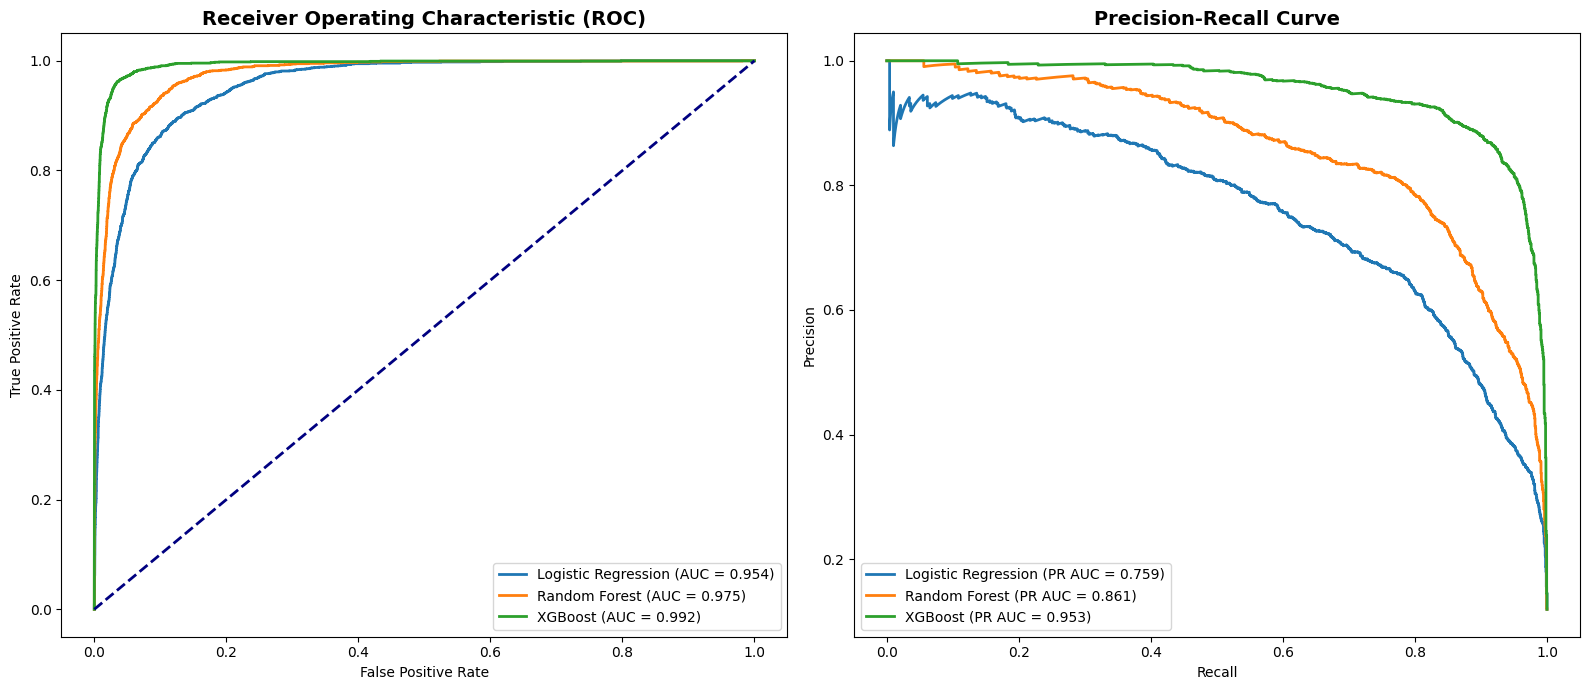

In [2]:
results_metrics = {}
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(16, 7))

for name, model in trained_models.items():
    # Select scaled/unscaled data natively
    X_te = X_test_scaled if name == 'Logistic Regression' else X_test
    
    # Predict
    y_prob = model.predict_proba(X_te)[:, 1]
    
    # Metrics
    roc_auc = roc_auc_score(y_test_churn, y_prob)
    pr, re, _ = precision_recall_curve(y_test_churn, y_prob)
    pr_auc = auc(re, pr)
    
    results_metrics[name] = {
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    }
    
    # Plot ROC
    fpr, tpr, _ = roc_curve(y_test_churn, y_prob)
    ax_roc.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')
    
    # Plot Precision-Recall
    ax_pr.plot(re, pr, lw=2, label=f'{name} (PR AUC = {pr_auc:.3f})')

ax_roc.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax_roc.set_title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(loc='lower right')

ax_pr.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.legend(loc='lower left')

plt.tight_layout()
plt.show()


--- Model Comparison ---
                      ROC-AUC    PR-AUC
XGBoost              0.992341  0.952540
Random Forest        0.974968  0.860699
Logistic Regression  0.954167  0.758563

--- Best Performing Algorithm: XGBoost ---
              precision    recall  f1-score   support

Retained (0)       1.00      0.96      0.98     13793
 Churned (1)       0.75      0.97      0.85      1872

    accuracy                           0.96     15665
   macro avg       0.87      0.96      0.91     15665
weighted avg       0.97      0.96      0.96     15665



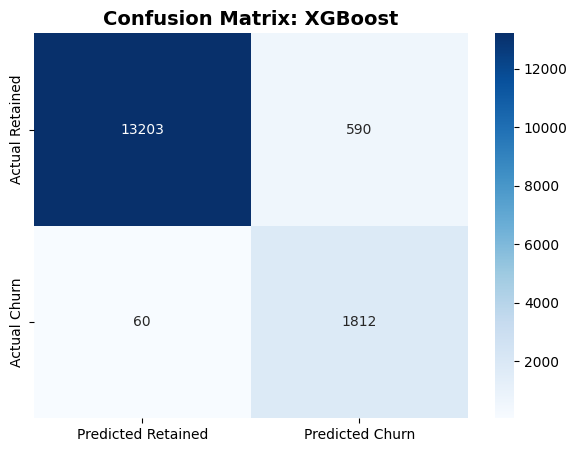

In [3]:
# Determine the best model using Precision-Recall Area Under Curve (ideal due to our Imbalance)
res_df = pd.DataFrame(results_metrics).T
print('--- Model Comparison ---')
print(res_df[['ROC-AUC', 'PR-AUC']].sort_values(by='PR-AUC', ascending=False))

best_model_name = res_df.sort_values(by='PR-AUC', ascending=False).index[0]
best_model = trained_models[best_model_name]

print(f'\n--- Best Performing Algorithm: {best_model_name} ---')
X_te = X_test_scaled if best_model_name == 'Logistic Regression' else X_test
y_pred_best = best_model.predict(X_te)

print(classification_report(y_test_churn, y_pred_best, target_names=['Retained (0)', 'Churned (1)']))

# Generate Confusion Matrix
cm = confusion_matrix(y_test_churn, y_pred_best)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Retained', 'Predicted Churn'],
            yticklabels=['Actual Retained', 'Actual Churn'])
plt.title(f'Confusion Matrix: {best_model_name}', fontsize=14, fontweight='bold')
plt.show()
